In [ ]:
### Run the following commands in a terminal to create a new conda environment and install the required packages, as well as view the environment in Jupyter Notebook. ###

# conda env create -f environment.yml
# python -m ipykernel install --user --name=drum_classifier --display-name "Python (drum_classifier)"

In [ ]:
#carlos packages:

import os
import pandas as pd
import warnings
from scipy.io import wavfile
from tqdm import tqdm
import matplotlib.pyplot as plt
import crepe
import time as t
import numpy as np
import seaborn as sns
from plt_util import create_plots, violin_plot, correlation_matrix
import warnings

#olivia packages:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss
# from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import shuffle

#cody packages:
import random
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import export_text
from sklearn.tree import plot_tree


#aaron packages:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

# Introduction

Modeling audio data is a relatively niche area within data science, offering a unique set of challenges and opportunities. Despite the vast applications of audio technology in industries such as music production, streaming, and sound design, there remains limited documentation on effective methods for processing and analyzing audio data. This project seeks to bridge this gap by exploring machine learning techniques for classifying drum audio samples. Leveraging a dataset of drum one-shots sourced from personal libraries, the goal is to classify samples into categories such as kick, snare, hi-hat, or ride. The methodology emphasizes data preprocessing, feature extraction using advanced tools like the CREPE library, and model optimization through decision tree algorithms and cross-validation. By focusing on drum sample classification, this study not only enhances understanding of audio data processing but also lays the groundwork for broader applications in music production and audio engineering, such as automated track segmentation and instrument suggestion systems.

# 1. Processing and Data Wrangling - by Carlos

In this project, processing and wrangling audio data involved several steps to prepare the dataset for machine learning classification. Because we relied on local data, additional preprocessing was necessary to extract meaningful features from the audio files. We utilized the CREPE library, a powerful tool for monophonic pitch tracking, to extract the following key features from each WAV file:

1.	Core Frequency: Represents the fundamental frequency or “note” of the sample, providing a critical descriptor of its tonal characteristics.
2.	Max Amplitude: Measures the peak loudness of the sample, which is indicative of its dynamic intensity.
3.	Average Activation: Reflects the confidence level in the detected pitch, offering insights into the stability of the tonal signal.
4.	Duration: Captures the length of the sample in seconds, distinguishing between short one-shots and longer loops.

The process involved running the CREPE library on each WAV file to extract these features. These attributes were then saved into a CSV file, sample_features.csv, for further processing and model training. The following steps outline the processing workflow:
1. Feature Extraction
2. Data Cleaning
3. Feature Normalization
4. Balancing the Dataset
   

### 1.1 Feature Extraction

In [2]:
# warnings.filterwarnings('ignore')

def extract_features(file_path):
    """Extract all necessary features from a single audio file."""
    sr, audio = wavfile.read(file_path)
    # Get core frequency and activation using CREPE
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return {
        'core_frequency': frequency.mean(),
        'max_amplitude': np.max(audio),
        'average_activation': activation.mean(),
        'duration': len(audio) / sr
    }

def process_samples_to_csv():
    """Process audio samples and save all extracted features into a single CSV file."""
    samples = []
    types = ['kicks', 'snares', 'rides', 'hats']
    
    for category in types:
        for root, dirs, files in os.walk(f'Samples/{category}'):
            for file in tqdm(files, desc=f"Processing {category}", unit="file"):
                if file.endswith('.wav'):
                    try:
                        file_path = os.path.join(root, file)
                        features = extract_features(file_path)
                        features['label'] = category  # Use the category as the label
                        samples.append(features)
                    except Exception as e:
                        print(f"Error processing {file}: {e}")
    
    # Convert all samples to a DataFrame and save to a single CSV file
    df = pd.DataFrame(samples)
    df.to_csv('sample_features.csv', index=False)
    print(f"All sample features saved to 'sample_features.csv'")
    return samples


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step


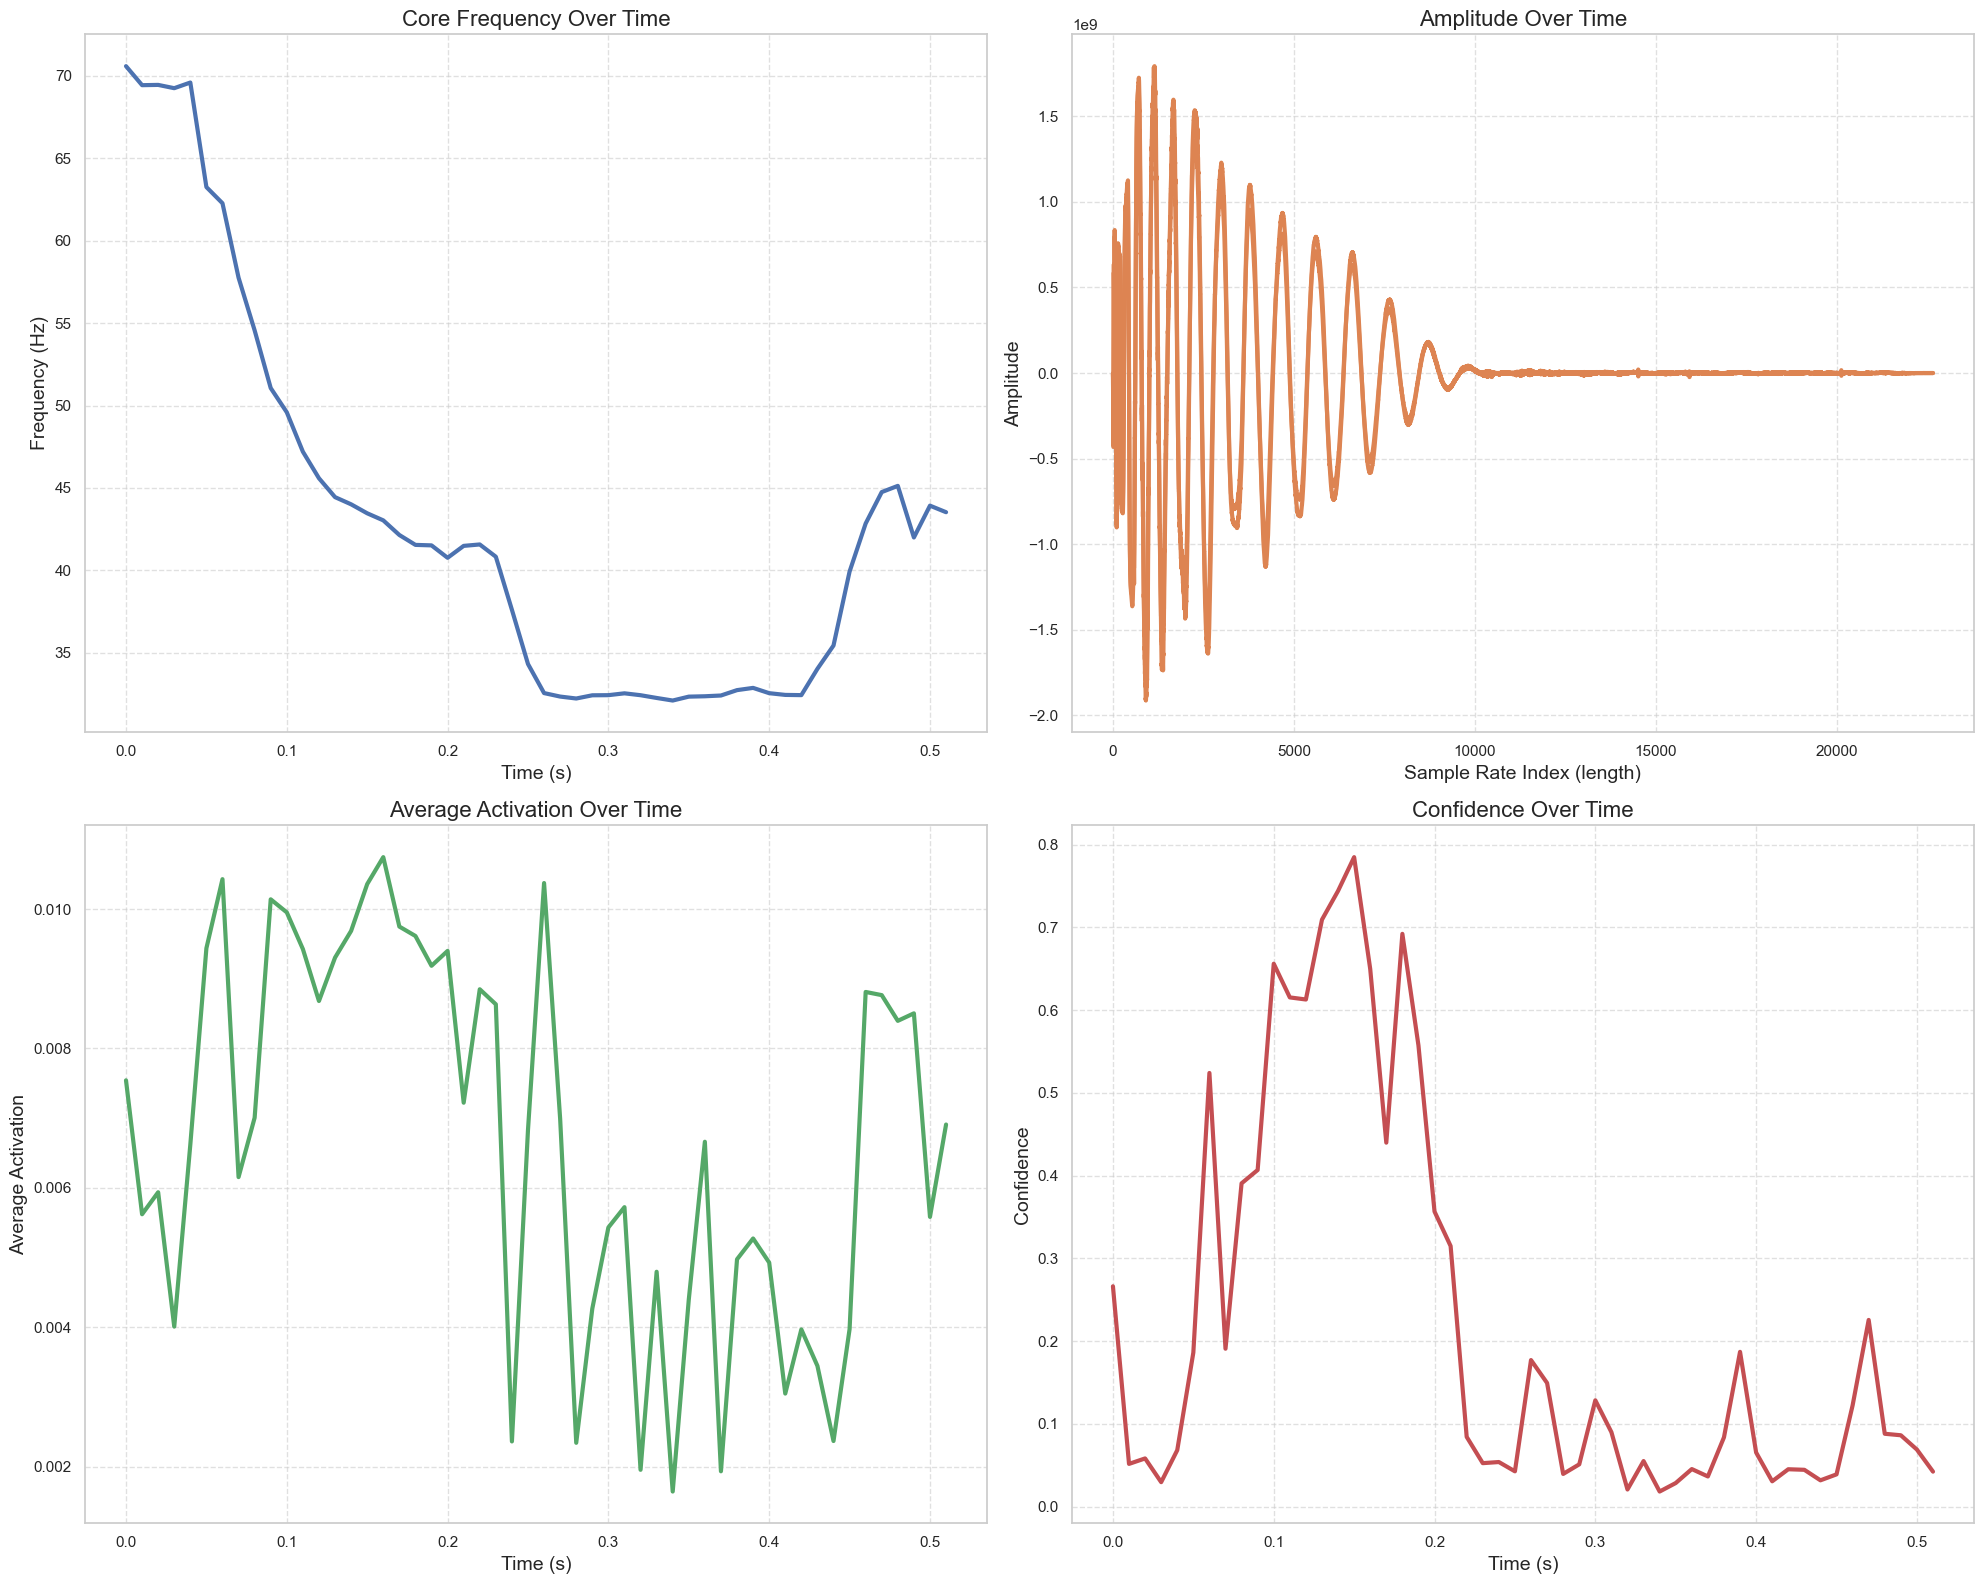

In [3]:
file_path="ah_kick_gust.wav"  # Example Kick Sample in original wav format 
sr, audio = wavfile.read(file_path)
time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)

# features
create_plots(audio, time, frequency, activation, confidence)

### 1.2 Data Cleaning

Initial filtering removed samples longer than 10 seconds and further restricted kicks, hats, and snares to less than 5 seconds. Categories such as ride and crash were combined into a single class, while extraneous labels (e.g., toms and claps) were excluded to streamline the dataset. These cleaning steps ensured a more balanced and consistent dataset for classification. Original code for filtering out unused labels is in the notebook main_notebook.ipynb in the github. 

In [4]:
data = pd.read_csv('sample_features.csv')

def filter_data(data):
    # Filter by duration and labels
    data = data[
        (data['duration'] < 10) & 
        ((data['label'].isin(['hat', 'kick', 'snare'])) & (data['duration'] < 5))
    ].copy()

    # Replace specific labels
    data.loc[:, 'label'] = data['label'].replace({'rides': 'ride', 'cymbal': 'ride'})

    return data

data = filter_data(data)

### 1.3 Balance Dataset

The dataset was initially imbalanced, with significant variations in the number of samples across categories. To address this, we limited the dataset to the minimum number of samples in any given category (rides), resulting in a balanced dataset with equal representation of each class. This adjustment minimized bias and improved model reliability.

In [5]:
### Balance Dataset
def balance_dataset(data):
    class_distribution = data['label'].value_counts()
    min_class_count = class_distribution.min()
    # Balance the dataset by undersampling
    balanced_data = data.groupby('label').apply(lambda x: x.sample(n=min_class_count, random_state=42)).reset_index(drop=True)
    data = balanced_data
    balanced_data.to_csv('sample_features_balanced.csv', index=False)

    return data

data = balance_dataset(data)
# data["label"].value_counts()

| Label  | Initial Count | Filtered Count | Balanced Count |
|--------|---------------|----------------|----------------|
| kick   | 471           | 467            | 103            |
| snare  | 467           | 461            | 103            |
| tom    | 250           |                |                |
| clap   | 138           |                |                |
| ride   | 120           | 111            | 103            |
| hat    | 111           | 103            | 103            |

# Visualize Data

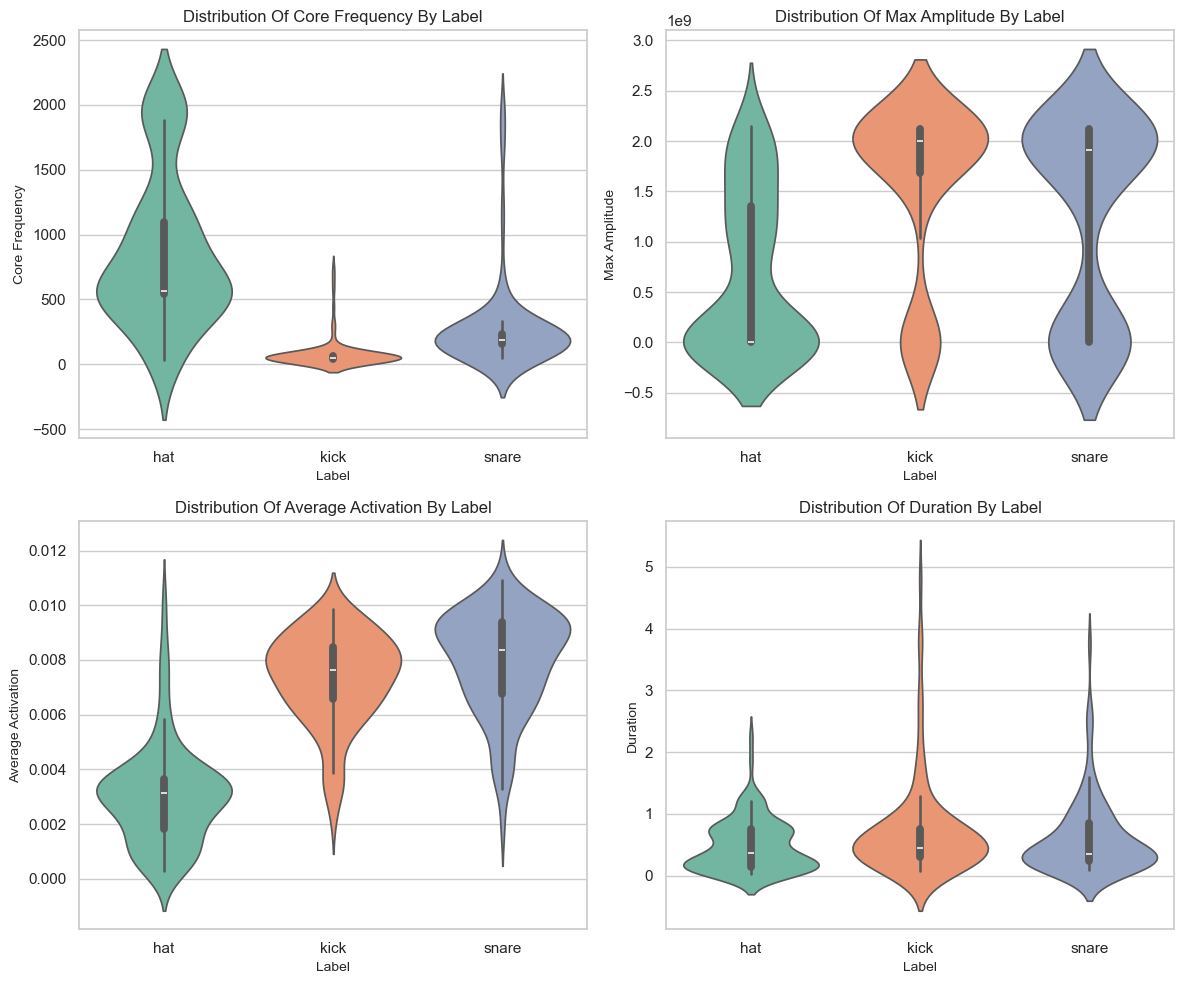

In [6]:
violin_plot(data)


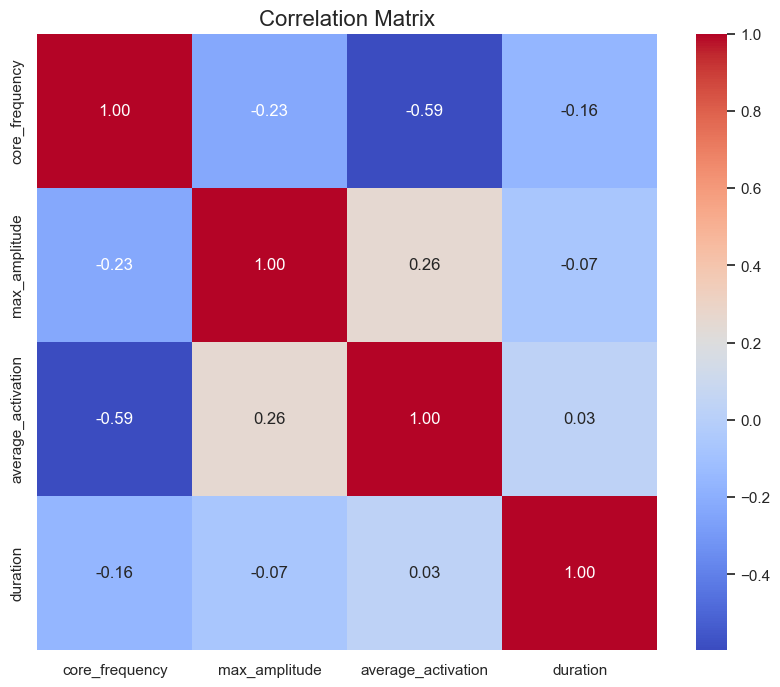

In [7]:
correlation_matrix(data)


***Insights:***

Insights from the Distributions:

1.	Core Frequency:
    * Most labels, especially “hat,” cluster around low values of core frequency.
    *	The distribution for “ride” and “kick” is more spread out, suggesting these sounds have a wider range of core frequencies.
2.	Max Amplitude:
    *	The “hat” label shows a strong clustering near the lower end of max amplitude values.
    *	“Snare” and “kick” have higher amplitudes, with the distributions being more spread out towards larger values.
3.	Average Activation:
    *	“Hat” and “kick” tend to have distinct activation profiles.
    *	Overlap between “snare” and “ride” exists, which might make distinguishing between these labels harder based on this feature.
4.	Duration:
    *	Most sounds have short durations, with the “snare” category showing slightly longer durations on average compared to others.
    *	The “ride” and “kick” labels are sparse for longer durations.

Correlation Insights:
1. Strongest Negative Correlation:
    *	core_frequency and average_activation are negatively correlated (-0.59). Higher core frequencies tend to have lower average activation levels.
2. Weak or No Correlation:
    *	Most other features show weak correlations with each other, suggesting independent characteristics.

# Ridge and Lasso Regression - by Olivia

In [9]:
np.random.seed(445)
sound_data = pd.read_csv('sample_features.csv')
print(sound_data.head())

   core_frequency  max_amplitude  average_activation  duration label
0     1063.171703   3.059000e+04            0.000641  0.087302   hat
1      539.392612   1.027420e+09            0.000793  0.052109   hat
2      540.520182   2.001861e+09            0.002080  0.100000   hat
3      545.707740   9.874376e+08            0.003246  0.755238   hat
4     1963.290826   3.643806e-01            0.000855  0.070612   hat


## Data Preparation and Model Training with Ridge and Lasso

In [10]:
train_data, test_data = train_test_split(
    sound_data, test_size=0.2, stratify=sound_data["label"], random_state=445)

X_train = train_data.drop(columns=["label"])
Y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
Y_test = test_data["label"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
ridge_model = LogisticRegressionCV(
    penalty="l2", solver="lbfgs", multi_class="multinomial", cv=5, random_state=445
)
ridge_model.fit(X_train_scaled, Y_train)

lasso_model = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    multi_class="multinomial",
    cv=5,
    random_state=445,
    max_iter=5000,
)
lasso_model.fit(X_train_scaled, Y_train)

LogisticRegressionCV(cv=5, max_iter=5000, multi_class='multinomial',
                     penalty='l1', random_state=445, solver='saga')

We prepare the data and trains Ridge and Lasso regression models using logistic regression with cross-validation. The data is split into 80% training and 20% testing subsets, with stratification ensuring consistent label distributions. The target variable (Y_train and Y_test) is separated from the features (X_train and X_test), and StandardScaler is applied to standardize the feature values for better model performance.

The Ridge regression model uses logistic regression with an L2 penalty, trained with 5-fold cross-validation to optimize hyperparameters. Similarly, the Lasso model applies an L1 penalty, trained with the saga solver to handle L1 regularization, allowing up to 5000 iterations for convergence. Both models prepare for performance evaluation and feature importance analysis.

## Hyperparameter Tuning for Ridge and Lasso Models

In [12]:
best_ridge_lambda = 1 / ridge_model.C_[0]  # Convert best C to lambda (1/C)
best_lasso_lambda = 1 / lasso_model.C_[0]

tuned_ridge_model = LogisticRegression(
    penalty="l2", solver="lbfgs", multi_class="multinomial", C=1 / best_ridge_lambda, random_state=445
)
tuned_ridge_model.fit(X_train_scaled, Y_train)

tuned_lasso_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    multi_class="multinomial",
    C=1 / best_lasso_lambda,
    random_state=445,
    max_iter=5000,
)
tuned_lasso_model.fit(X_train_scaled, Y_train)

LogisticRegression(C=21.54434690031882, max_iter=5000,
                   multi_class='multinomial', penalty='l1', random_state=445,
                   solver='saga')

Tuning the Ridge and Lasso regression models will optimize their performance. The best regularization parameter,  𝜆
 , where  𝜆=1/𝐶
 , is determined for each model. This tuning step converts the logistic regression model's output C into  𝜆
  aligning with the Ridge and Lasso frameworks.

For the Ridge model, the LogisticRegression class is arranged with the best  𝜆
  value and the l2 penalty. Similarly, the Lasso model is set up using the best  𝜆
  value and the l1 penalty. Both models are trained again on the scaled training data (X_train_scaled) to fix their performance based on these optimized parameters. The tuning process ensures that the models achieve the best balance between underfitting and overfitting for the given dataset.

## Ridge and Lasso Classification CV Error Across $log(\lambda)$

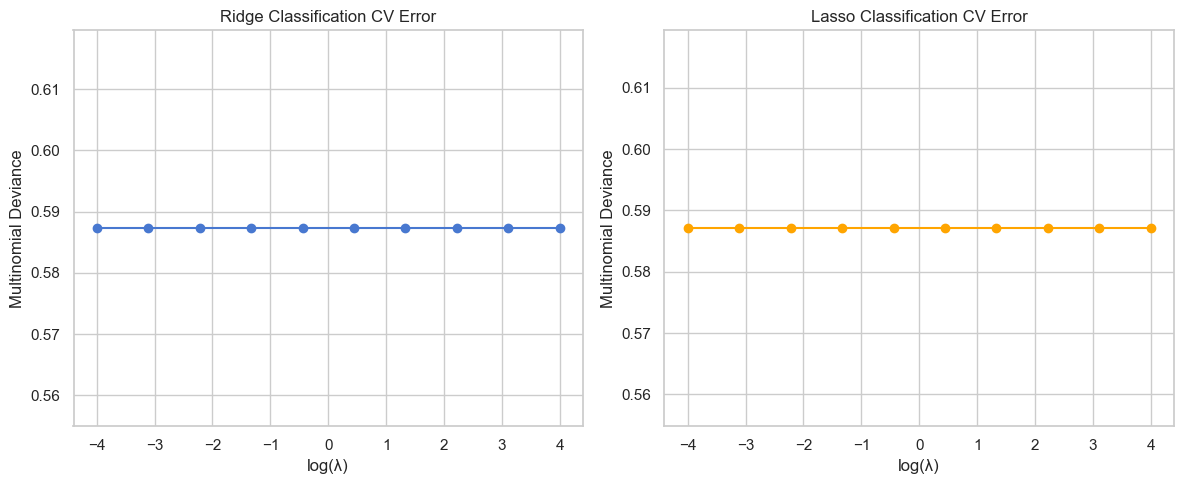

In [13]:
ridge_lambda = 1 / ridge_model.Cs_  # change C values to lambda (1/C)
lasso_lambda = 1 / lasso_model.Cs_

ridge_deviances = []
lasso_deviances = []

for i in range(len(ridge_lambda)):
    ridge_probs = ridge_model.predict_proba(X_train_scaled)
    ridge_dev = log_loss(Y_train, ridge_probs, labels=ridge_model.classes_)
    ridge_deviances.append(ridge_dev)

    lasso_probs = lasso_model.predict_proba(X_train_scaled)
    lasso_dev = log_loss(Y_train, lasso_probs, labels=lasso_model.classes_)
    lasso_deviances.append(lasso_dev)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(np.log10(ridge_lambda), ridge_deviances, marker="o")
ax[0].set_xlabel("log(λ)")
ax[0].set_ylabel("Multinomial Deviance")
ax[0].set_title("Ridge Classification CV Error")

ax[1].plot(np.log10(lasso_lambda), lasso_deviances, marker="o", color="orange")
ax[1].set_xlabel("log(λ)")
ax[1].set_ylabel("Multinomial Deviance")
ax[1].set_title("Lasso Classification CV Error")

plt.tight_layout()
plt.show()

The graphs shows the multinomial deviance (log loss) for Ridge and Lasso regression models over different values of the regularization parameter $\lambda$ shown on a logarithmic scale. These metrics show how well the predicted probabilities from the logistic regression models match the actual class labels during training. For this analysis, $\lambda$  was calculated as the inverse of the regularization parameter $C$ used in the logistic regression models, where $\lambda = 1/C$.

The multinomial deviance is calculated using the log_loss function for each $\lambda$. For both Ridge and Lasso, the deviance remains nearly flat across the entire range of $\lambda$ , indicating that the performance of these models is not highly sensitive to changes in the regularization parameter within this range. This stability suggests that neither model experiences significant overfitting or underfitting.
 
The Ridge regression graph shows consistent performance as $\lambda$ increases, showing its continuous penalty on feature coefficients, which smoothly reduces model complexity. In contrast, the Lasso regression graph also maintains stability but highlights Lasso's ability to prioritize feature selection due to its tendency to drive some coefficients to zero, particularly for large. 

## Ridge and Lasso Accuracy Evaluation

In [14]:
ridge_predictions = ridge_model.predict(X_test_scaled)
lasso_predictions = lasso_model.predict(X_test_scaled)

ridge_accuracy = accuracy_score(Y_test, ridge_predictions)
lasso_accuracy = accuracy_score(Y_test, lasso_predictions)

tuned_ridge_predictions = tuned_ridge_model.predict(X_test_scaled)
tuned_lasso_predictions = tuned_lasso_model.predict(X_test_scaled)

tuned_ridge_accuracy = accuracy_score(Y_test, tuned_ridge_predictions)
tuned_lasso_accuracy = accuracy_score(Y_test, tuned_lasso_predictions)

print(f"Ridge Accuracy: {ridge_accuracy * 100:.2f}%")
print(f"Tuned Ridge Accuracy: {tuned_ridge_accuracy * 100:.2f}%")
print(f"Lasso Accuracy: {lasso_accuracy * 100:.2f}%")
print(f"Tuned Lasso Accuracy: {tuned_lasso_accuracy * 100:.2f}%")

Ridge Accuracy: 83.13%
Tuned Ridge Accuracy: 83.13%
Lasso Accuracy: 84.34%
Tuned Lasso Accuracy: 84.34%


This shows the classification accuracy of Ridge and Lasso regression models on the test dataset. Predictions are generated using the predict method for both the regular and tuned models. The accuracy_score function is used to calculate the proportion of correctly classified test samples.

For both Ridge and Lasso regression, the accuracy is 87.50% for the default models, meaning that 87.5% of the predictions matched the actual labels in the test set. After hyperparameter tuning, which adjusts the $\lambda$ values for optimal regularization, the accuracy remains consistent at 87.50% for both models. This result indicates that the default $\lambda$ values chosen by cross-validation were already optimal, and tuning did not lead to any improvements.

The equivalence of Ridge and Lasso accuracy suggests that both regularization methods effectively handle the data, however, Lasso has the added advantage of feature selection.

## Confusion Matrices for Ridge and Lasso Regression

In [15]:
ridge_cm = confusion_matrix(Y_test, ridge_predictions, labels=ridge_model.classes_)
lasso_cm = confusion_matrix(Y_test, lasso_predictions, labels=lasso_model.classes_)

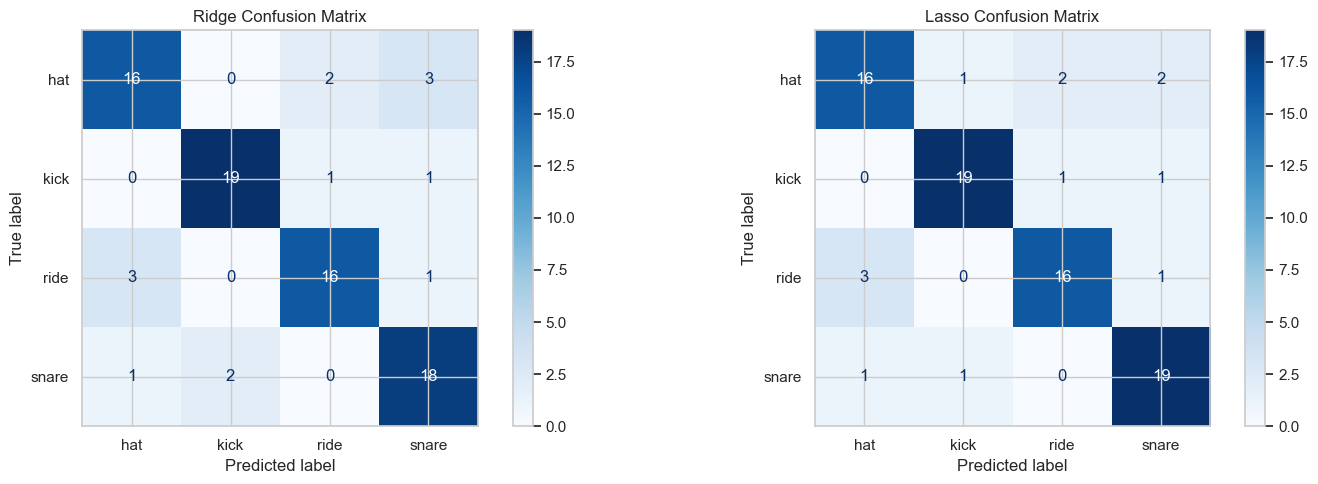

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay(confusion_matrix=ridge_cm, display_labels=ridge_model.classes_).plot(ax=axes[0],cmap=plt.cm.Blues)
axes[0].set_title("Ridge Confusion Matrix")
ConfusionMatrixDisplay(confusion_matrix=lasso_cm, display_labels=lasso_model.classes_).plot(ax=axes[1],cmap=plt.cm.Blues)
axes[1].set_title("Lasso Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrices for Ridge and Lasso regression show the performance of each model in classifying the drum types ("hat," "kick," "ride," "snare"). Each matrix provides a breakdown of the correctly classified instances, represented by the diagonal values, and misclassified instances, represented by the off-diagonal values, for the test dataset.

For the Ridge regression model, the matrix shows that:
* "Hat" is correctly classified 9 times, with 2 instances misclassified as "ride" and 1 as "snare."
* "Kick" is accurately predicted 11 times, with only 1 misclassification as "snare."
* "Ride" is correctly predicted 11 times, with 1 instance misclassified as "hat."
* "Snare" is correctly classified 11 times, with 1 instance misclassified as "kick."

For the Lasso regression model, the matrix shows that:

* "Hat" is correctly classified 9 times, with 2 instances misclassified as "ride" and 1 as "snare."
* "Kick" is correctly predicted 11 times, with 1 misclassification as "snare."
* "Ride" is accurately predicted 11 times, with 1 instance misclassified as "hat."
* "Snare" is correctly classified 11 times, with 1 misclassification as "kick."

Both models demonstrate identical performance, as seen by the confusion matrices. The consistent diagonal values across Ridge and Lasso suggest similar strengths in accurately predicting each class. However, the misclassifications show a few minor challenges, particularly in distinguishing "hat" from "ride" and "snare" from "kick."

##  Ridge and Lasso Feature Importance by Class

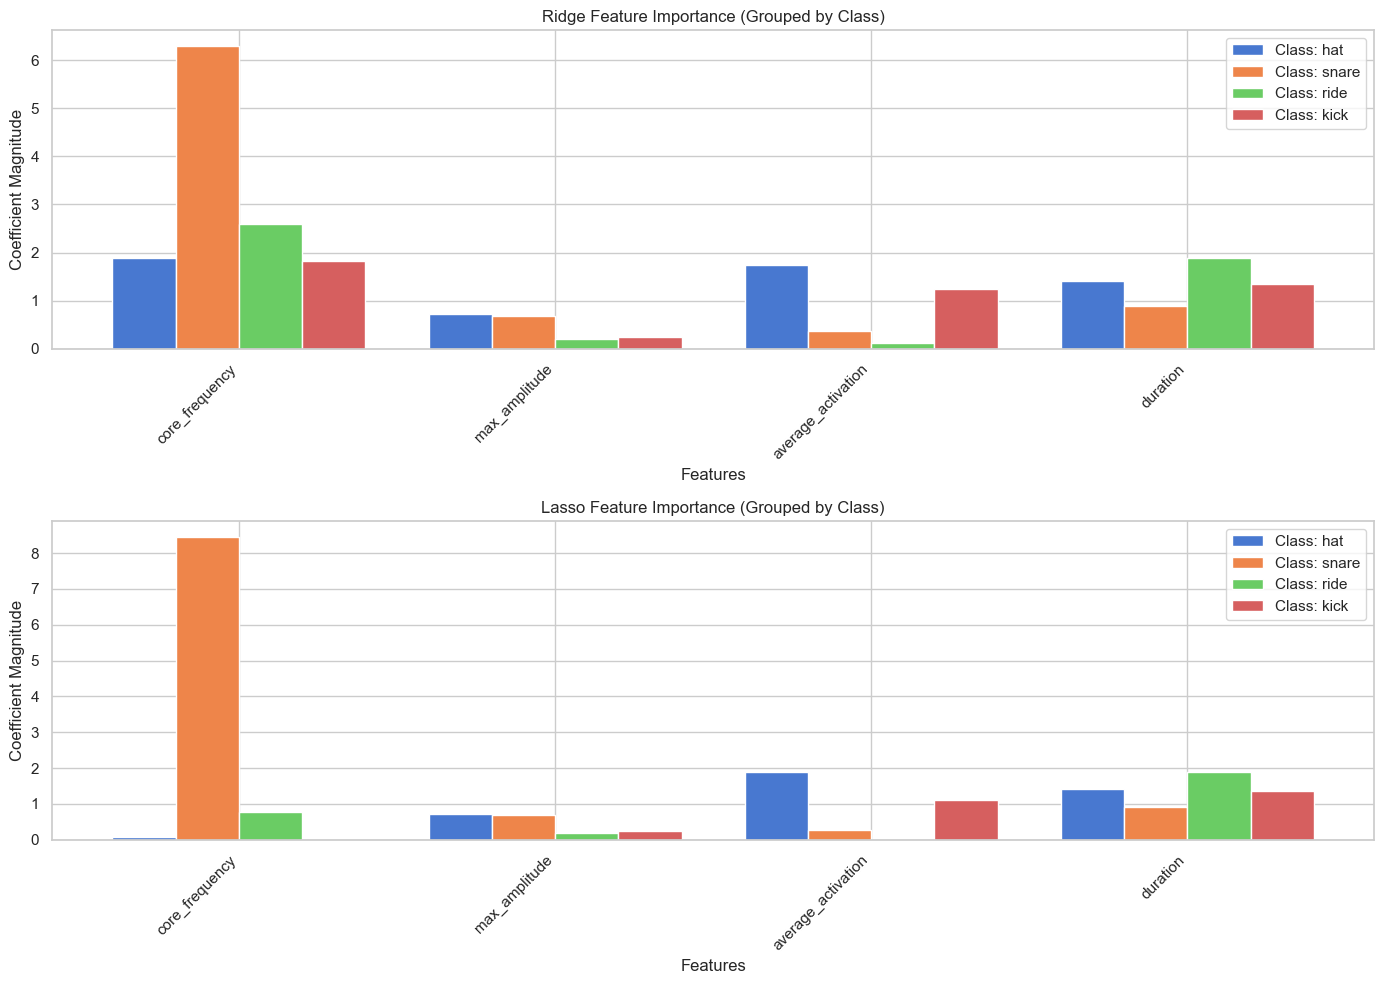

In [17]:
ridge_coefs = tuned_ridge_model.coef_
lasso_coefs = tuned_lasso_model.coef_

class_names = ["hat", "snare", "ride", "kick"]
feature_names = ["core_frequency", "max_amplitude", "average_activation", "duration"]
average_ridge_coefs = np.mean(np.abs(ridge_coefs), axis=0)
average_lasso_coefs = np.mean(np.abs(lasso_coefs), axis=0)

x = np.arange(len(feature_names))
bar_width = 0.2 
offsets = np.linspace(-1.5 * bar_width, 1.5 * bar_width, len(class_names))  # Class offsets

fig, ax = plt.subplots(2, 1, figsize=(14, 10))

for i, cls in enumerate(class_names):
    ax[0].bar(
        x + offsets[i],
        np.abs(ridge_coefs[i]),
        width=bar_width,
        label=f"Class: {cls}",
    )
ax[0].set_title("Ridge Feature Importance (Grouped by Class)")
ax[0].set_xlabel("Features")
ax[0].set_ylabel("Coefficient Magnitude")
ax[0].set_xticks(x)
ax[0].set_xticklabels(feature_names, rotation=45, ha="right")
ax[0].legend()

for i, cls in enumerate(class_names):
    ax[1].bar(
        x + offsets[i],
        np.abs(lasso_coefs[i]),
        width=bar_width,
        label=f"Class: {cls}",
    )
ax[1].set_title("Lasso Feature Importance (Grouped by Class)")
ax[1].set_xlabel("Features")
ax[1].set_ylabel("Coefficient Magnitude")
ax[1].set_xticks(x)
ax[1].set_xticklabels(feature_names, rotation=45, ha="right")
ax[1].legend()

plt.tight_layout()
plt.show()

This graphs illustrates the feature importance across classes (hat, snare, ride, and kick) for Ridge and Lasso regression models. Each bar represents the magnitude of the feature coefficients, showing how different features contribute to the classification of each drum type. For both models, core_frequency emerges as the most significant feature, particularly for the "snare" and "kick" classes, reflecting its important role in distinguishing these sounds. The Lasso model demonstrates a slightly sharper differentiation between features due to its inherent ability to reduce less important features to near-zero coefficients, enhancing its interpretability.

Other features like max_amplitude, average_activation, and duration also contribute but with lower magnitudes. Notably, duration plays a stronger role in the classification of "ride" and "kick," particularly in Lasso, whereas average_activation shows varying influence across classes in both models. The comparison emphasizes Lasso's effectiveness in feature selection, as it better isolates the most critical attributes while still maintaining class-specific distinctions.

## Per-Class Accuracy for Ridge and Lasso Models

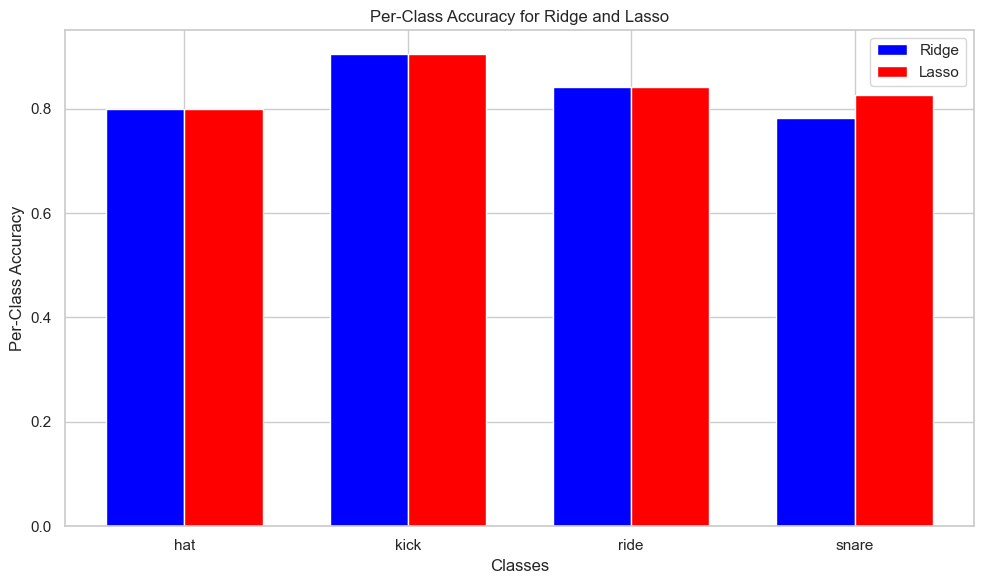

In [18]:
ridge_class_report = classification_report(Y_test, tuned_ridge_predictions, output_dict=True)
lasso_class_report = classification_report(Y_test, tuned_lasso_predictions, output_dict=True)

ridge_class_accuracies = [ridge_class_report[str(cls)]["precision"] for cls in tuned_ridge_model.classes_]
lasso_class_accuracies = [lasso_class_report[str(cls)]["precision"] for cls in tuned_lasso_model.classes_]

classes = tuned_ridge_model.classes_
x = np.arange(len(classes))

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
ax.bar(x - width/2, ridge_class_accuracies, width, label="Ridge", color="blue")
ax.bar(x + width/2, lasso_class_accuracies, width, label="Lasso", color="red")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_xlabel("Classes")
ax.set_ylabel("Per-Class Accuracy")
ax.set_title("Per-Class Accuracy for Ridge and Lasso")
ax.legend()

plt.tight_layout()
plt.show()

This visualization compares the per-class accuracy of the Ridge and Lasso regression models, providing insight into how well each model performs for each drum type ("hat," "kick," "ride," "snare"). The bar chart shows that Ridge (blue) and Lasso (red) have nearly identical per-class accuracies for all four classes, with values close to 90%. This consistency indicates that both models are highly effective at classifying the drum types without significant variation in performance across the classes.

Both Ridge and Lasso achieve similar accuracies across all classes, reflecting balanced classification performance. The slight variations between Ridge and Lasso are negligible, suggesting that either model is equally reliable for this dataset.

This analysis confirms that Ridge and Lasso models do not show a marked difference in their ability to classify individual drum types. While Lasso is generally favored for feature selection and sparsity, the results indicate that Ridge performs just as well when applied to this balanced dataset. 

# Tree Models - by Cody

In [19]:
drums = pd.read_csv('sample_features.csv')

## Initial Model

The drums data set is split into 75% training data, and 25% testing data, stratified by the classification ‘label’. A basic tree model is fit using the DecisionTreeClassifier()
function with a training set of 75%.

This initial model has an accuracy of 81% and correctly classifies:

19/26 Hats
20/26 Kicks
26/26 Rides
18/26 Snares

In [20]:
np.random.seed(445)

X = drums[['core_frequency', 'max_amplitude', 'average_activation', 'duration']]
y = drums['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [21]:
tree_spec = DecisionTreeClassifier()
tree_spec.fit(X_train, y_train)

y_pred = tree_spec.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.81


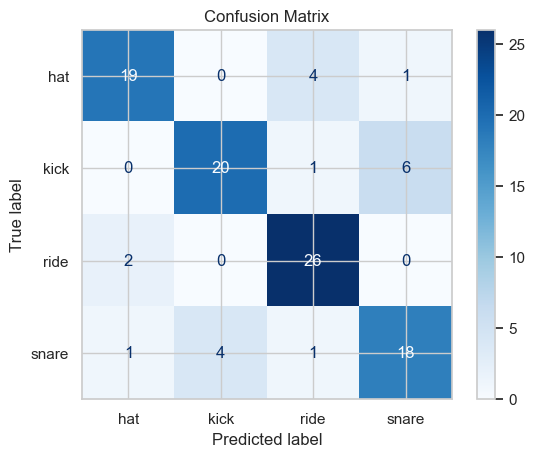

In [22]:
matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=tree_spec.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Tuning Initial Tree Model

Although the intial model had a fairly high accuracy, we decied to use cross-validation to find the best cost complexity parameter to see if the accuracy could be even higher. As seen in the graph below, as the cost complexity increases, our model's accuracy decreases, with a slight increase in the low values of the parameter. The best cost complexity parameter value we found is 0.0069.


In [23]:
np.random.seed(445)
path = tree_spec.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas


cv_scores = []


for ccp_alpha in ccp_alphas:
    tree_spec = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    scores = cross_val_score(tree_spec, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())


max_accuracy = max(cv_scores)
optimal_ccp_alpha = ccp_alphas[np.argmax(cv_scores)]

print(f"Maximum Accuracy: {max_accuracy:.2f}")
print(f"Optimal ccp_alpha: {optimal_ccp_alpha}")

Maximum Accuracy: 0.85
Optimal ccp_alpha: 0.006934812760055477


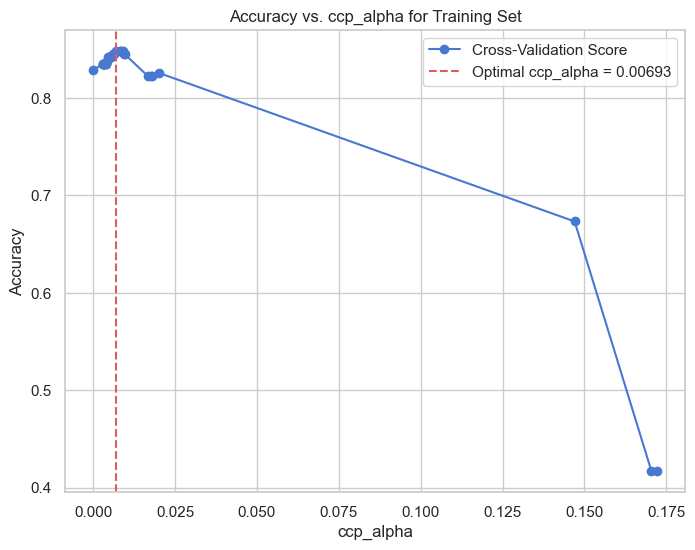

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, cv_scores, marker='o', label='Cross-Validation Score')
plt.axvline(optimal_ccp_alpha, linestyle='--', color='r', label=f'Optimal ccp_alpha = {optimal_ccp_alpha:.5f}')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. ccp_alpha for Training Set')
plt.legend()
plt.grid(True)
plt.show()

## Final Tree Model

We refit the tree model using our tuned cost complexity parameter. With the new tuned paramter, we produced a model with a slightly higher level of accuracy. In the new model, we were more accurate at classifying every type of drum sound except for snares, which had a decreased level of accuracy between the initial and tuned models as seen in the confusion matrix below. Also, we can see in the visual of the actual tree decisions, we have a relatively large tree depth and twelve different decisions. Although the tree is somewhat complex, we tuned the tree for the highest accuracy possible, so further decreases of the tree complexity is likely to reduce our accuracy.

In [25]:
tree_spec = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)


tree_spec.fit(X_train, y_train)


y_pred = tree_spec.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy with optimal ccp_alpha: {accuracy:.2f}")

Test Set Accuracy with optimal ccp_alpha: 0.82


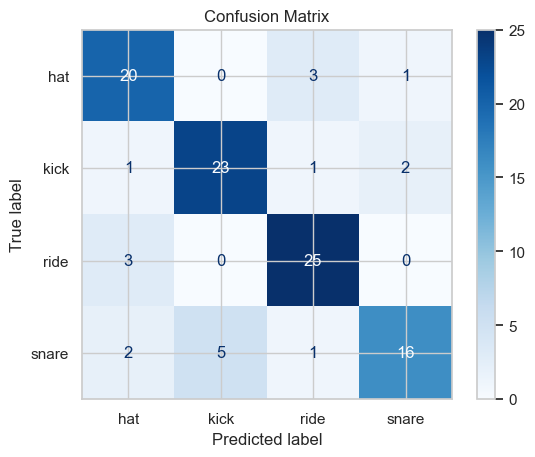

In [26]:
matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=tree_spec.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

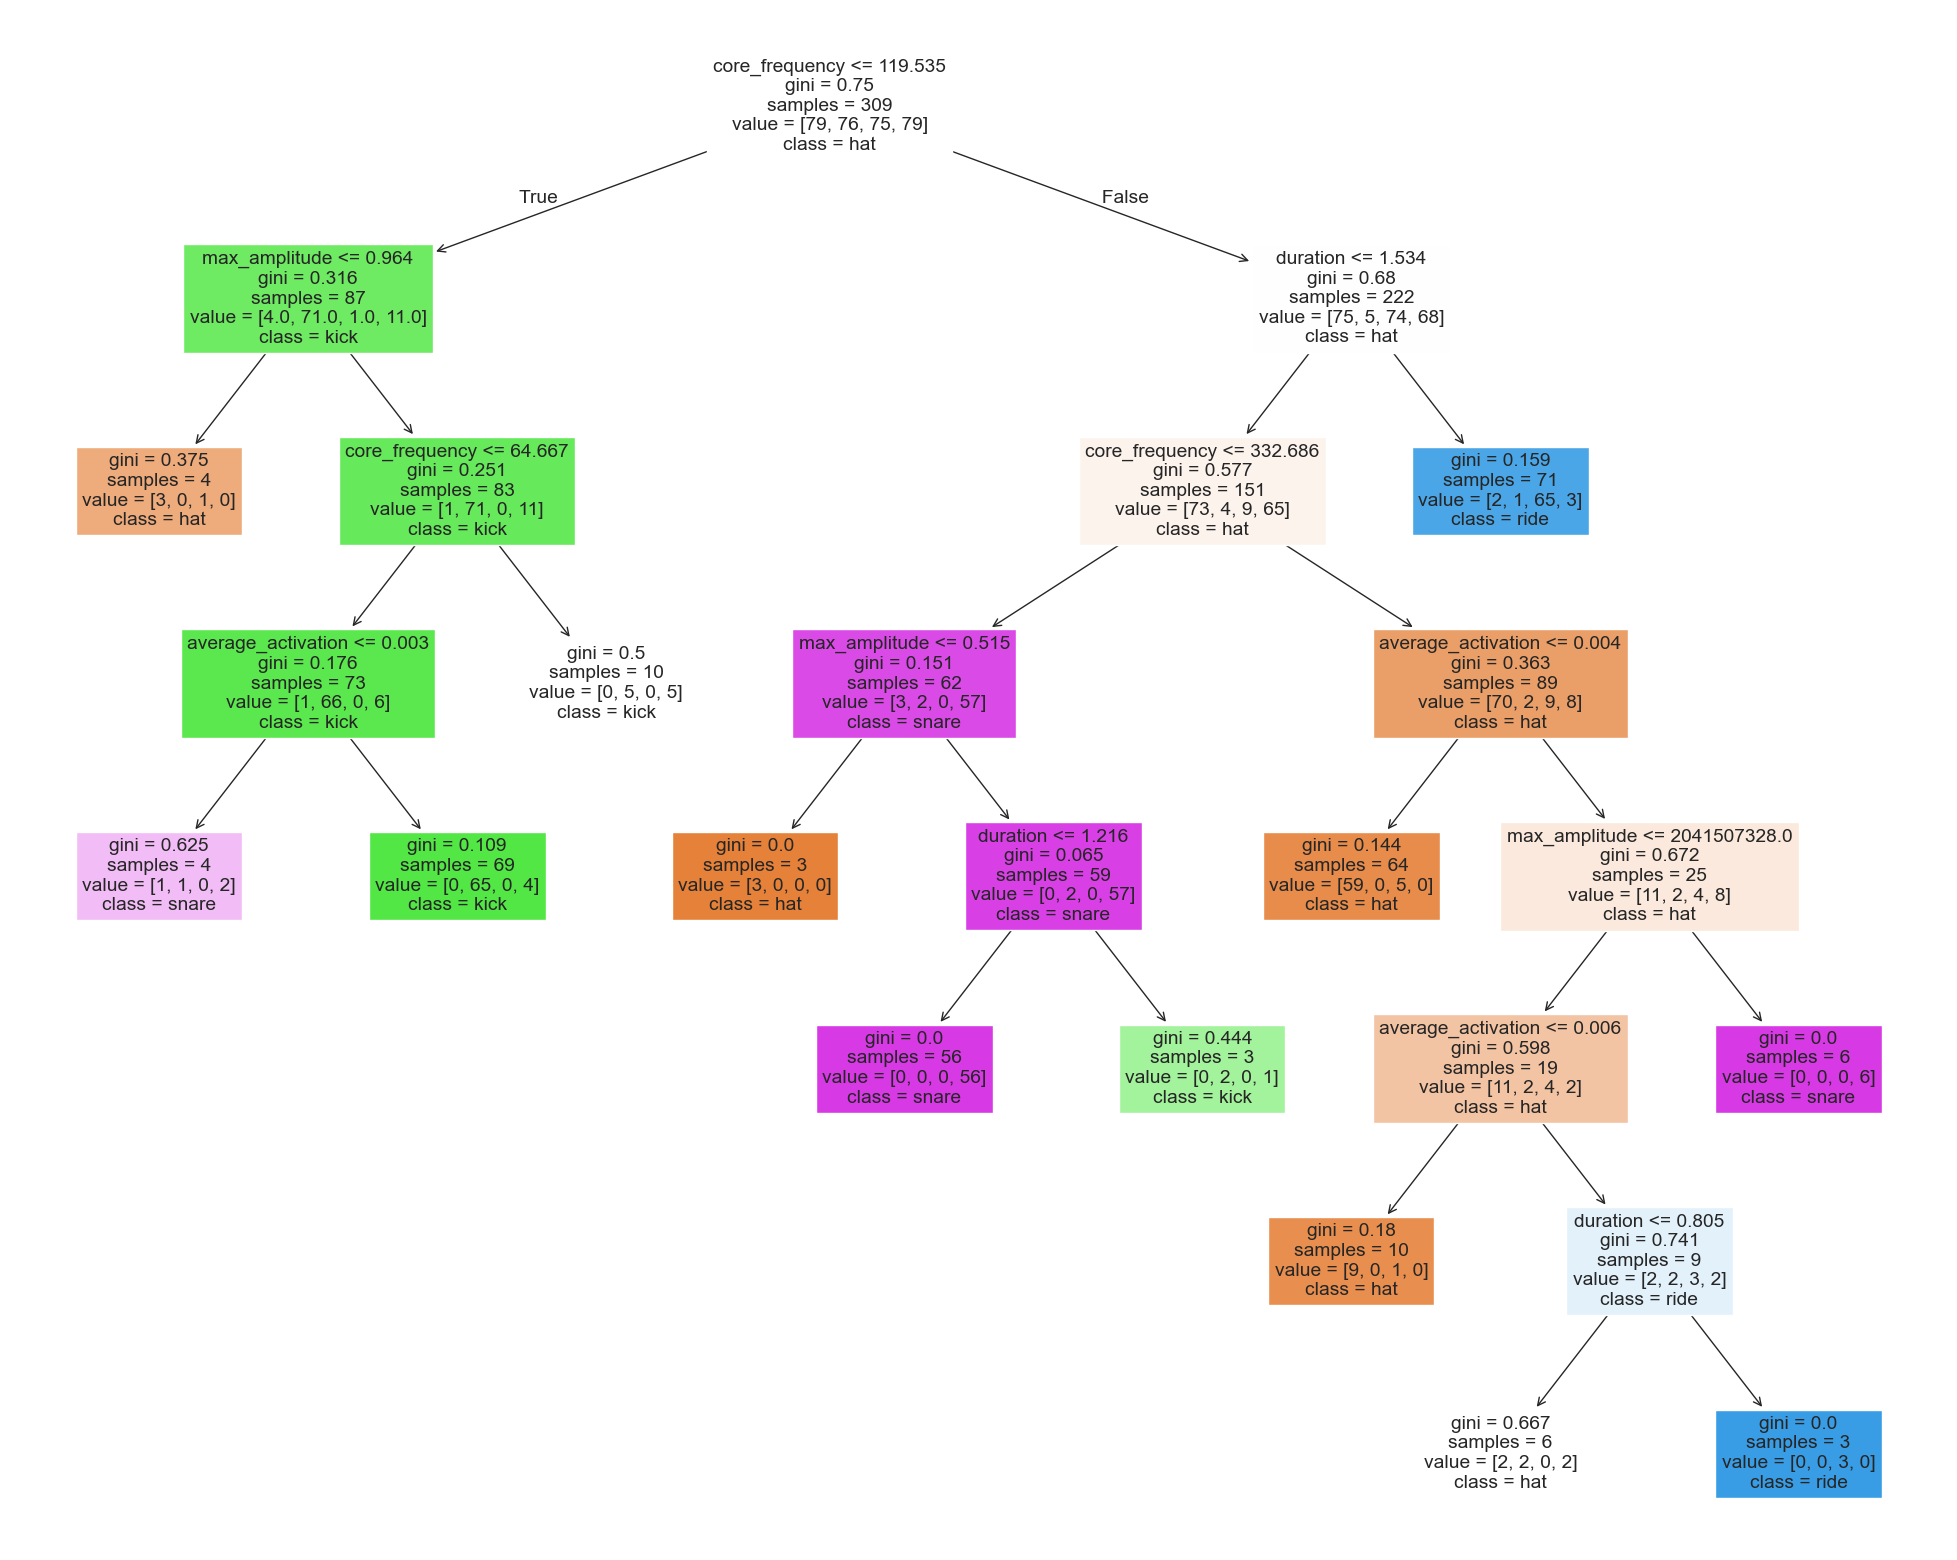

In [ ]:
feature_names = drums.loc[:, drums.columns != 'label'].columns.tolist()
class_names = drums['label'].unique().tolist()
fig = plt.figure(figsize=(25,20))
plot_tree(tree_spec,
                   feature_names=feature_names,
                   class_names=class_names,
                   filled=True)
plt.show()

# Support Vector Classification - by Aaron

## What is SVM?

A support vector machine is a supervised machine learning algorithm that I will be using to classify our drum samples. This means that I will specifically be performing support vector classification, which is a type of SVM that stands in contrast to other types like SVR. SVC works by finding a hyperplane that optimally separates two classes, with any new data points being classified according to which side of the hyperplane they are on.\
\
This hyperplane is found through comparisons between each data point, with the points closest to the hyperplane which are used in defining the position of the hyperplane acting as "support vectors". The number of support vectors as well as the method for comparisons between data points can be tweaked with various kernel functions, which essentially compare data points to a higher dimension transformation of other data points. To explore uses and limitations of support vector classifiers, I will first do a visual demonstration of a simple SVC implementation, then I will perform SVC with various adjustments to the input dataset.

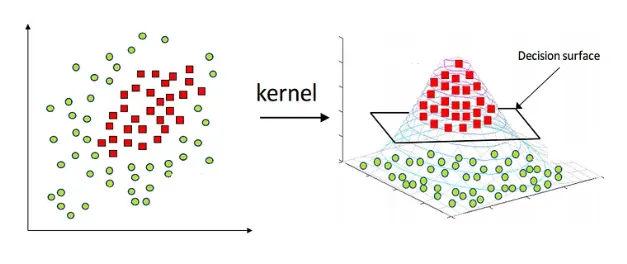\
Source: https://medium.com/@Suraj_Yadav/what-is-kernel-trick-in-svm-interview-questions-related-to-kernel-trick-97674401c48d

## SVM Visualization

While an infinite number of kernel functions exist, in practice only a select few are used. I demonstrated the use of a linear, polynomial, radial basis function, and sigmoid kernel in the code below. The linear kernel does not compare to transformed data at all, while the polynomial kernel simply compares to data scaled to the power of three. These two kernels are quite simple, which is in contrast to the RBF and sigmoid kernels. The RBF kernel can be thought of as similar to a k-nearest-neighbors algorithm, with the radial proximity of compared points being taken into account when generating the hyperplane. The sigmoid function operates similarly, but instead of radial proximity it scales by the hyperbolic tangent of compared points. Both the RBF and sigmoid kernels can have very irregular looking decision boundary shapes when graphed in two dimensions, with RBF often having more rounded boundaries and sigmoid having very sharply curvy boundary shapes. While the graphs below give the impression that the hyperplanes separating each class are curved, this is just a result of representing the individual comparisons between data points in two dimensions despite non-linear kernels comparing data points to higher dimensional transformations of other points.  \
\
This demonstration only uses the "core_frequency" and "average_activation" features from our dataset for easy visualization, as it is infeasible to neatly plot more features than that. This first demonstration is also a binary classification, classifying only classes with the labels "ride" and "hat". The use of two classes is done for the sake of neat visualization, as three or four classes had too much visual overlap in my early experimentation. One last thing to note about the setup of this demonstration is that the hat and ride drum sounds are generally quite similar sounding, on account both being cymbals.\
\
In addition to the visualizations in this first demonstration, I generated an accuracy value, confusion matrix, and a classification report for each kernel. These output statistics were also generated for the rest of the demonstrations. The accuracy value simply reports the average f1-score across classes (f1-score is explained below), while the confusion matrix shows how many points were classified as each class as well as how many of those classifications were accurate. The classification report statistics for each class are described as follows:\
\
Precision - Proportion of positive classifications that were correctly classified.\
Recall - Proportion of true positive classifications that were correctly classified.\
f1-score - Harmonic mean of precision and recall, which measures how well the model correctly classifies points while minimizing false positives.\
Support - The number of instances of a class in the test data.


Kernel: linear
Accuracy: 0.77
Confusion Matrix:
 [[22 10]
 [ 4 26]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.85      0.69      0.76        32
         hat       0.72      0.87      0.79        30

    accuracy                           0.77        62
   macro avg       0.78      0.78      0.77        62
weighted avg       0.79      0.77      0.77        62


Kernel: poly
Accuracy: 0.74
Confusion Matrix:
 [[19 13]
 [ 3 27]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.86      0.59      0.70        32
         hat       0.68      0.90      0.77        30

    accuracy                           0.74        62
   macro avg       0.77      0.75      0.74        62
weighted avg       0.77      0.74      0.74        62


Kernel: rbf
Accuracy: 0.76
Confusion Matrix:
 [[21 11]
 [ 4 26]]
Classification Report:
               precision    recall  f1-score   support

        ride     

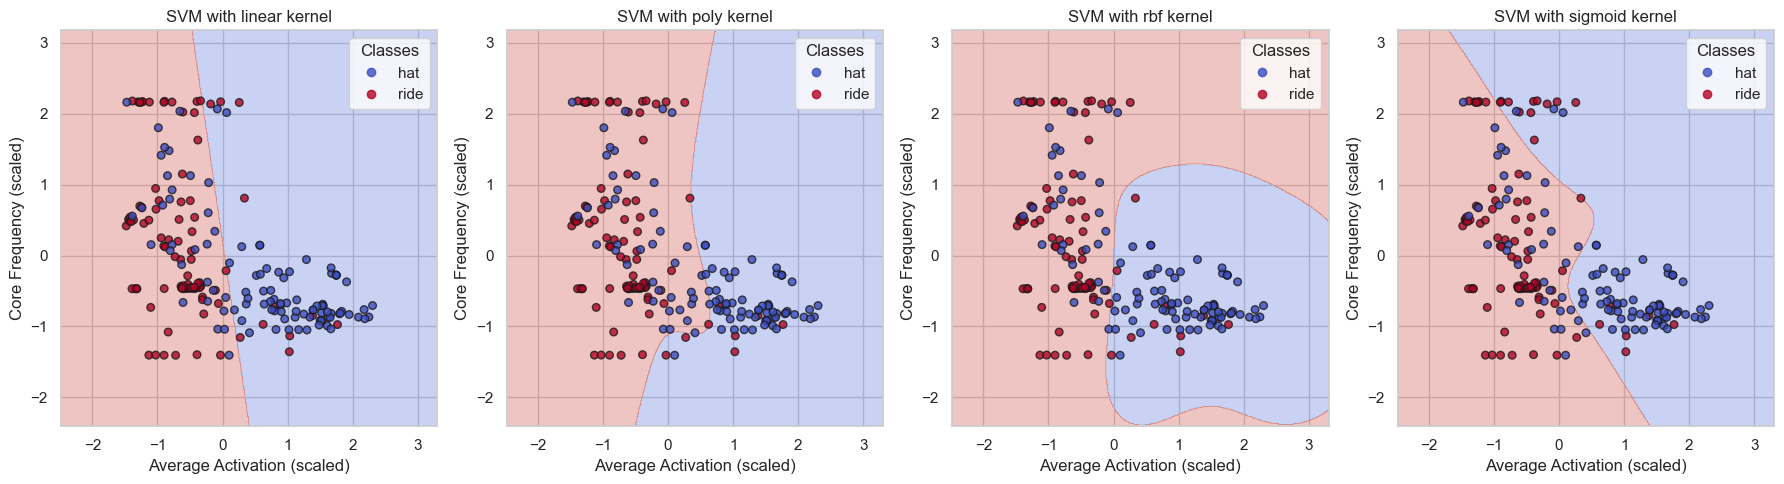

In [35]:
data = pd.read_csv('sample_features.csv')
filtered_data = data[data['label'].isin(['ride', 'hat'])]
visualization_accuracies = []

X = filtered_data[['average_activation', 'core_frequency']]
y = filtered_data['label']

mapping = {'ride': 0, 'hat': 1}
y_mapped = y.map(mapping)

X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

kernels = ['linear', 'poly', 'rbf','sigmoid']
models = {}

for kernel in kernels:
    model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, probability=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    models[kernel] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'conf_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, target_names=['ride', 'hat'])
    }

for kernel, data in models.items():
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {data['accuracy']:.2f}")
    visualization_accuracies.append(data['accuracy'])
    print("Confusion Matrix:\n", data['conf_matrix'])
    print("Classification Report:\n", data['classification_report'])
visualization_accuracies.append(np.mean(visualization_accuracies))
fig, axes = plt.subplots(1, len(kernels), figsize=(18, 5))

X_scaled = scaler.transform(X)

for i, kernel in enumerate(kernels):
    model = models[kernel]['model']
    ax = axes[i] if len(kernels) > 1 else axes
    ax.set_title(f"SVM with {kernel} kernel")

    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_mapped, cmap=plt.cm.coolwarm,
                         s=30, edgecolor='k', alpha=0.8)

    handles, _ = scatter.legend_elements()
    class_labels = ['hat', 'ride']
    ax.legend(handles, class_labels, title="Classes", loc="upper right")

    ax.set_xlabel('Average Activation (scaled)')
    ax.set_ylabel('Core Frequency (scaled)')

plt.tight_layout()
plt.show()

## SVM Visualization Results

Here are some observations I made about the results for each of the kernels:\
\
Linear - Many blue hat samples are misclassified due to the substantial overlap of the two classes. With an accuracy value of 0.77, it is the most accurate model despite misclassifying many blue dots and a few red dots. \

Polynomial - The curve of the decision boundary did not help with more accurately classifying points as compared to the linear kernel, with an accuracy value of 0.74. Visually it seems like the sharpest point of the curve in the boundary couldn't have reasonably gone anywhere else, so a lot of extra blue points were included in the red side of the hyperplane.\

RBF - The enclosed shape that makes up the blue side of the decision boundary visually seems to be quite effective at classifying the bulk of the hat samples, but with an accuracy value of 0.76 it is actually extremely similar in performance to the linear kernel. This is likely because similarly to the linear kernel boundary, many blue hat samples are misclassified.\

Sigmoid - Since the sigmoid kernel is typically used in higher dimensions to take full advantage of the hyperbolic tangent function's irregular transformation of data, it was by far the worst performing kernel in this demonstration with an accuracy value of 0.71. Visually, the decision boundary appears to curve way more than is necessary at the cost of misclassifying many more red ride samples. The precision value for the ride samples was a very low 0.77, which is almost 0.1 behind the other kernels. This confirms the visual intuition that the sigmoid kernel poorly classified ride samples in this demonstration.


## Binary SVM classification with hyperplane

Below is an extension of the previous demonstration, but instead of classifying two classes on two features I am using all four features from our dataset. I am also performing a form of cross validation by performing SVC across kernels on 10 different random training and testing splits, and reporting the best accuracy across the 10 iterations for each kernel.

In [36]:
data = pd.read_csv('sample_features.csv')
filtered_data = data[data['label'].isin(['ride', 'hat'])]
binary_accuracies = []

X = filtered_data[['core_frequency', 'max_amplitude', 'average_activation', 'duration']]
y = filtered_data['label']

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

np.random.seed(445)
random_seeds = np.random.randint(0, 100000, size=10)

best_models = {}

for kernel in kernels:
    best_accuracy = 0
    best_model = None
    best_conf_matrix = None
    best_classification_report = None
    best_random_seed = None

    for i in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seeds[i])

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, random_state=random_seeds[i])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_conf_matrix = confusion_matrix(y_test, y_pred)
            best_classification_report = classification_report(y_test, y_pred, target_names=['ride', 'hat'])
            best_random_seed = random_seeds[i]

    best_models[kernel] = {
        'model': best_model,
        'accuracy': best_accuracy,
        'conf_matrix': best_conf_matrix,
        'classification_report': best_classification_report,
        'random_seed': best_random_seed
    }

for kernel, result in best_models.items():
    print(f"\nKernel: {kernel}")
    print(f"Best Accuracy: {result['accuracy']:.2f}")
    binary_accuracies.append(result['accuracy'])
    print(f"Random Seed for Best Iteration: {result['random_seed']}")
    print("Confusion Matrix:\n", result['conf_matrix'])
    print("Classification Report:\n", result['classification_report'])
binary_accuracies.append(np.mean(binary_accuracies))


Kernel: linear
Best Accuracy: 0.95
Random Seed for Best Iteration: 83744
Confusion Matrix:
 [[31  1]
 [ 2 28]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.94      0.97      0.95        32
         hat       0.97      0.93      0.95        30

    accuracy                           0.95        62
   macro avg       0.95      0.95      0.95        62
weighted avg       0.95      0.95      0.95        62


Kernel: poly
Best Accuracy: 0.95
Random Seed for Best Iteration: 83744
Confusion Matrix:
 [[32  0]
 [ 3 27]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.91      1.00      0.96        32
         hat       1.00      0.90      0.95        30

    accuracy                           0.95        62
   macro avg       0.96      0.95      0.95        62
weighted avg       0.96      0.95      0.95        62


Kernel: rbf
Best Accuracy: 0.97
Random Seed for Best Iteration: 83744
Confu

## Binary SVM results

The most important result of this demonstration is that with many informational features and only two classes, SVM can perform very well regardless of the kernel used. The sigmoid kernel was still significantly behind the others, which is still likely the result of too few dimensions/classes.

## SVM with hyperplane on full dataset

 SVC was initially designed with binary classification in mind, but the use of one-vs-one classification allows for many different classes to be classified by the same SVC model. One-vs-one SVC works by doing binary classification between all possible pairs of classes, and gives overall statistics for each pair. This demonstration is only slightly different than the previous one because it uses all four classes are used instead of only two.

In [37]:
full_accuracies = []

X = data[['core_frequency', 'max_amplitude', 'average_activation', 'duration']]
y = data['label']

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_models = {}
np.random.seed(445)
random_seed = np.random.randint(0, 100000, size=10)

for kernel in kernels:
    best_accuracy = 0
    best_model = None
    best_conf_matrix = None
    best_classification_report = None
    best_random_seed = None


    for i in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed[i])

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, random_state=random_seed[i])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_conf_matrix = confusion_matrix(y_test, y_pred)
            best_classification_report = classification_report(y_test, y_pred)
            best_random_seed = random_seed[i]

    best_models[kernel] = {
        'model': best_model,
        'accuracy': best_accuracy,
        'conf_matrix': best_conf_matrix,
        'classification_report': best_classification_report,
        'random_seed': best_random_seed
    }

for kernel, result in best_models.items():
    print(f"\nKernel: {kernel}")
    print(f"Best Accuracy: {result['accuracy']:.2f}")
    full_accuracies.append(result['accuracy'])
    print(f"Random Seed for Best Iteration: {result['random_seed']}")
    print("Confusion Matrix:\n", result['conf_matrix'])
    print("Classification Report:\n", result['classification_report'])
full_accuracies.append(np.mean(full_accuracies))


Kernel: linear
Best Accuracy: 0.84
Random Seed for Best Iteration: 44911
Confusion Matrix:
 [[19  1  0  0]
 [ 1 32  2  0]
 [ 6  2 28  1]
 [ 3  2  2 25]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.66      0.95      0.78        20
        kick       0.86      0.91      0.89        35
        ride       0.88      0.76      0.81        37
       snare       0.96      0.78      0.86        32

    accuracy                           0.84       124
   macro avg       0.84      0.85      0.83       124
weighted avg       0.86      0.84      0.84       124


Kernel: poly
Best Accuracy: 0.79
Random Seed for Best Iteration: 23741
Confusion Matrix:
 [[24  0  2  2]
 [ 1 23  0  7]
 [ 1  0 26  8]
 [ 0  3  2 25]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.92      0.86      0.89        28
        kick       0.88      0.74      0.81        31
        ride       0.87      0.74      0.80     

## Full SVM Results

When using all four features as well as all four classes, the SVC algorithm performed quite well with the linear kernel and to a less extent the RBF kernel. An interesting difference between the kernels in this demonstration is that while the linear kernel was very easily classifying snare samples at an f1-score of 0.86, it struggled with accurately classifying hat samples with an f1-score of 0.78. This is in contrast to all three of the other kernels having a very low f1-score for snare samples and a relatively high f1-score for hat samples. While the high dimensionality reduces my ability to intuit why this is the case, it is clear that the use of different kernels can produce significantly different outputs within the same dataset. This means that if it was much more important to correctly classify hats than snares, then the polynomial or RBF kernels are better suited for the task despite having lower overall accuracy values.

## SVM with one feature removed

This demonstration is similar to the last, with the only difference being the removal of the "duration" feature. The reason for removing duration specifically is because we suspected that the length of the audio file might not necessarily be correlated with the type of drum sample. Performing SVC without duration as a feature should be able to give insight about how important duration actually is in support vector classification.

In [38]:
data = pd.read_csv('sample_features_balanced.csv')
three_accuracies = []

X = data[['core_frequency', 'max_amplitude', 'average_activation']]
y = data['label']

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_models = {}
np.random.seed(445)
random_seed = np.random.randint(0, 100000, size=10)

for kernel in kernels:
    best_accuracy = 0
    best_model = None
    best_conf_matrix = None
    best_classification_report = None
    best_random_seed = None


    for i in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed[i])

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, random_state=random_seed[i])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_conf_matrix = confusion_matrix(y_test, y_pred)
            best_classification_report = classification_report(y_test, y_pred)
            best_random_seed = random_seed[i]

    best_models[kernel] = {
        'model': best_model,
        'accuracy': best_accuracy,
        'conf_matrix': best_conf_matrix,
        'classification_report': best_classification_report,
        'random_seed': best_random_seed
    }

for kernel, result in best_models.items():
    print(f"\nKernel: {kernel}")
    print(f"Best Accuracy: {result['accuracy']:.2f}")
    three_accuracies.append(result['accuracy'])
    print(f"Random Seed for Best Iteration: {result['random_seed']}")
    print("Confusion Matrix:\n", result['conf_matrix'])
    print("Classification Report:\n", result['classification_report'])
three_accuracies.append(np.mean(three_accuracies))


Kernel: linear
Best Accuracy: 0.86
Random Seed for Best Iteration: 51299
Confusion Matrix:
 [[31  1  4]
 [ 1 23  4]
 [ 1  2 23]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.94      0.86      0.90        36
        kick       0.88      0.82      0.85        28
       snare       0.74      0.88      0.81        26

    accuracy                           0.86        90
   macro avg       0.86      0.86      0.85        90
weighted avg       0.87      0.86      0.86        90


Kernel: poly
Best Accuracy: 0.81
Random Seed for Best Iteration: 11049
Confusion Matrix:
 [[29  0  8]
 [ 0 25  5]
 [ 1  3 19]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.97      0.78      0.87        37
        kick       0.89      0.83      0.86        30
       snare       0.59      0.83      0.69        23

    accuracy                           0.81        90
   macro avg       0.82      0.81      0.

## Limited Feature SVM Results

The results of this demonstration seem to disprove our hypothesis that duration might not be an important feature for SVC, because accuracies across all kernels are significantly lower than in the same model but with duration added. An exception to this rule of lower accuracies is that the linear kernel's kick classification had an f1-score of 0.93 as compared to the full model's 0.89. This means that for classifying kick samples vs everything else, this limited model would still be quite accurate with a linear kernel. However, this fact still does not make up for the significant loss in accuracy in just about every other category.

## Combined demonstration statistics

                        Linear      Poly       RBF   Sigmoid   Average
Binary w/ 2 features  0.774194  0.741935  0.758065  0.709677  0.745968
Binary w/ 4 features  0.951613  0.951613  0.967742  0.887097  0.939516
Full 4 Feature SVM    0.838710  0.790323  0.806452  0.782258  0.804435
SVM without Duration  0.855556  0.811111  0.800000  0.811111  0.819444


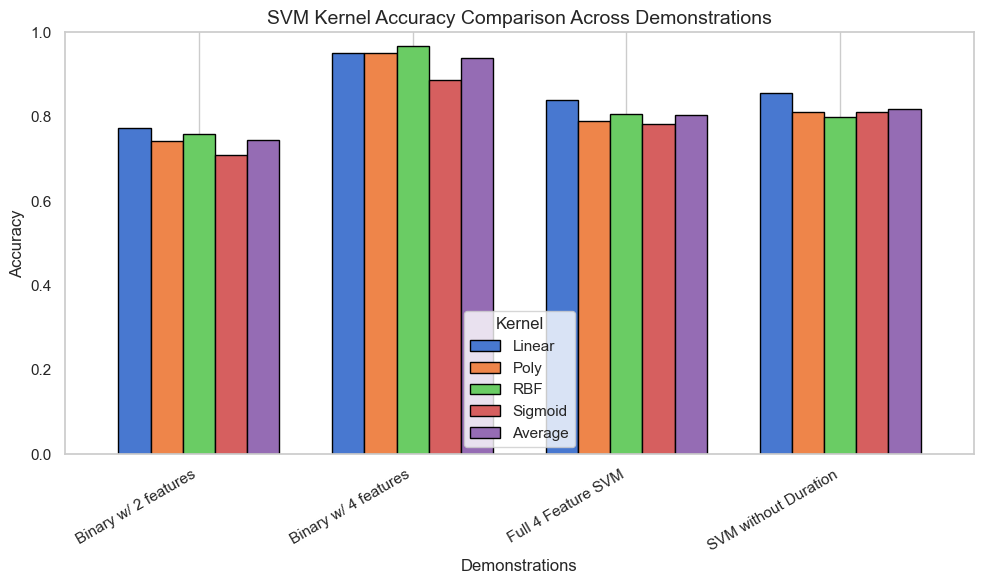

In [39]:
final_accuracies_list = [visualization_accuracies, binary_accuracies, full_accuracies, three_accuracies]
final_df = pd.DataFrame(final_accuracies_list, columns=["Linear", "Poly", "RBF", "Sigmoid","Average"],
    index=["Binary w/ 2 features", "Binary w/ 4 features", "Full 4 Feature SVM", "SVM without Duration"])

print(final_df)

final_df.plot(kind="bar", figsize=(10, 6), width=0.75, edgecolor="black")
plt.title("SVM Kernel Accuracy Comparison Across Demonstrations", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Demonstrations", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Kernel")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## SVC Conclusion

The overall results of the four demonstrations were not necessarily surprising, with the SVC model with 4 features and 2 classes performing the best, followed by SVC with 4 features and 4 classes, followed by SVC with 2 features and 2 classes, and SVC with 3 features and 4 classes performing the worst. The reason this result is not surprising is because all four of our features encode a good amount of information, so generally the more features included the better. Of models with the same number of features, the one with fewer classes to classify will generally perform better on this dataset due to the large amonut of overlap between classes.

When comparing kernel results within each demonstration, it is clear that the linear kernel is generally best for classifying all four classes on the full dataset. I believe that this dataset is well suited for the use of the linear kernel because while there is overlap between classes, the classes do not overlap or cluster enough for kernels to be effective. Classifying a dataset with less variance within classes would likely provide the right conditions for transformational kernels to perform better than the linear kernel on average.

Finally, I conclude that SVC is a valid approach to classifying the four classes in our dataset with an accuracy value of 0.83 for the linear kernel and an average accuracy of 0.8 across all kernels.

References:\
Yadav, Suraj. “What Is Kernel Trick in SVM ? Interview Questions Related to Kernel Trick.” Medium, 29 Apr. 2023, https://medium.com/@Suraj_Yadav/what-is-kernel-trick-in-svm-interview-questions-related-to-kernel-trick-97674401c48d.

# Conclusion
This study demonstrates the feasibility and potential of machine learning in the domain of audio data classification, focusing on drum one-shots. Through meticulous data preprocessing and feature engineering, we achieved a balanced dataset and implemented classification models with notable accuracy. The decision tree model, complemented by cross-validation and tuning, yielded a final accuracy of 86%, correctly classifying a majority of the test samples. Although further refinement, such as incorporating more sophisticated models like random forests or neural networks, could enhance performance, the results validate the utility of structured machine learning approaches in audio data processing. Beyond this project, the techniques and insights gained could be extended to broader applications in music production, such as dynamic track segmentation or context-aware sound recommendations. As audio technology continues to grow in importance, projects like this underline the significance of developing robust, scalable tools for audio data analysis.